# 257. Binary Tree Paths
https://leetcode.com/problems/binary-tree-paths/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| BFS | O(n) | O(n) | Level-order traversal tracking paths |
| **DFS (Optimal)** | **O(n)** | **O(n)** | Recursive DFS building path strings |

## Methodology

Use DFS to traverse the tree. At each node, append the node value to the current path. When a leaf node is reached (no left or right child), add the complete path to the result list. The path is built using `->` as separator between node values.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<string> BinaryTreePaths(TreeNode root) {
        var result = new List<string>();
        if (root != null) Dfs(root, "", result);
        return result;
    }
    
    private void Dfs(TreeNode node, string path, List<string> result) {
        path += node.val;
        if (node.left == null && node.right == null) {
            result.Add(path);
            return;
        }
        path += "->";
        if (node.left != null) Dfs(node.left, path, result);
        if (node.right != null) Dfs(node.right, path, result);
    }
}

### Python

In [ ]:
class Solution:
    def binaryTreePaths(self, root: Optional[TreeNode]) -> list[str]:
        result = []
        def dfs(node, path):
            path += str(node.val)
            if not node.left and not node.right:
                result.append(path)
                return
            path += '->'
            if node.left:
                dfs(node.left, path)
            if node.right:
                dfs(node.right, path)
        if root:
            dfs(root, '')
        return result

### Go

In [ ]:
func binaryTreePaths(root *TreeNode) []string {
    var result []string
    var dfs func(node *TreeNode, path string)
    dfs = func(node *TreeNode, path string) {
        path += strconv.Itoa(node.Val)
        if node.Left == nil && node.Right == nil {
            result = append(result, path)
            return
        }
        path += "->"
        if node.Left != nil {
            dfs(node.Left, path)
        }
        if node.Right != nil {
            dfs(node.Right, path)
        }
    }
    if root != nil {
        dfs(root, "")
    }
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;

impl Solution {
    pub fn binary_tree_paths(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<String> {
        let mut result = Vec::new();
        if let Some(node) = root {
            Self::dfs(&node, String::new(), &mut result);
        }
        result
    }
    
    fn dfs(node: &Rc<RefCell<TreeNode>>, mut path: String, result: &mut Vec<String>) {
        let n = node.borrow();
        path.push_str(&n.val.to_string());
        if n.left.is_none() && n.right.is_none() {
            result.push(path);
            return;
        }
        path.push_str("->");
        if let Some(ref left) = n.left {
            Self::dfs(left, path.clone(), result);
        }
        if let Some(ref right) = n.right {
            Self::dfs(right, path, result);
        }
    }
}

## Example Scenarios

1. **Common Case** — `root = [1,2,3,null,5]`
   **Input:** A tree with root 1, left child 2 (right child 5), and right child 3.
   DFS traverses left: $1 \to 2 \to 5$ (leaf), then right: $1 \to 3$ (leaf). Output: `["1->2->5", "1->3"]`.

2. **Slightly Complex** — `root = [1,2,3,4,5,6,7]`
   **Input:** A complete binary tree of depth 3 with $2^3 - 1 = 7$ nodes.
   Four leaf nodes produce four paths: `["1->2->4", "1->2->5", "1->3->6", "1->3->7"]`. Each path has length 3.

3. **Edge Case: Time Factor** — A left-skewed tree with $n=5000$ nodes: $1 \to 2 \to 3 \to \cdots \to 5000$
   **Input:** Each node only has a left child, forming a single chain.
   Only one path exists with 5000 nodes. The string concatenation builds a path of length $O(n)$, and total work is $O(n^2)$ due to string copies — the worst case for time.

4. **Edge Case: Space Factor** — `root = [1]`
   **Input:** A single-node tree (minimum valid input).
   The root is itself a leaf, so output is `["1"]`. Recursion depth is 1, using $O(1)$ stack space.

5. **Almost-Impossible but Plausible** — A complete binary tree of depth 20 ($2^{20}-1 \approx 10^6$ nodes)
   **Input:** Over one million nodes with $2^{19} = 524{,}288$ leaves.
   Each path is 20 nodes long, and we produce $524{,}288$ paths. Total output size is $\sim 10^7$ characters — pushing memory limits for the result list.

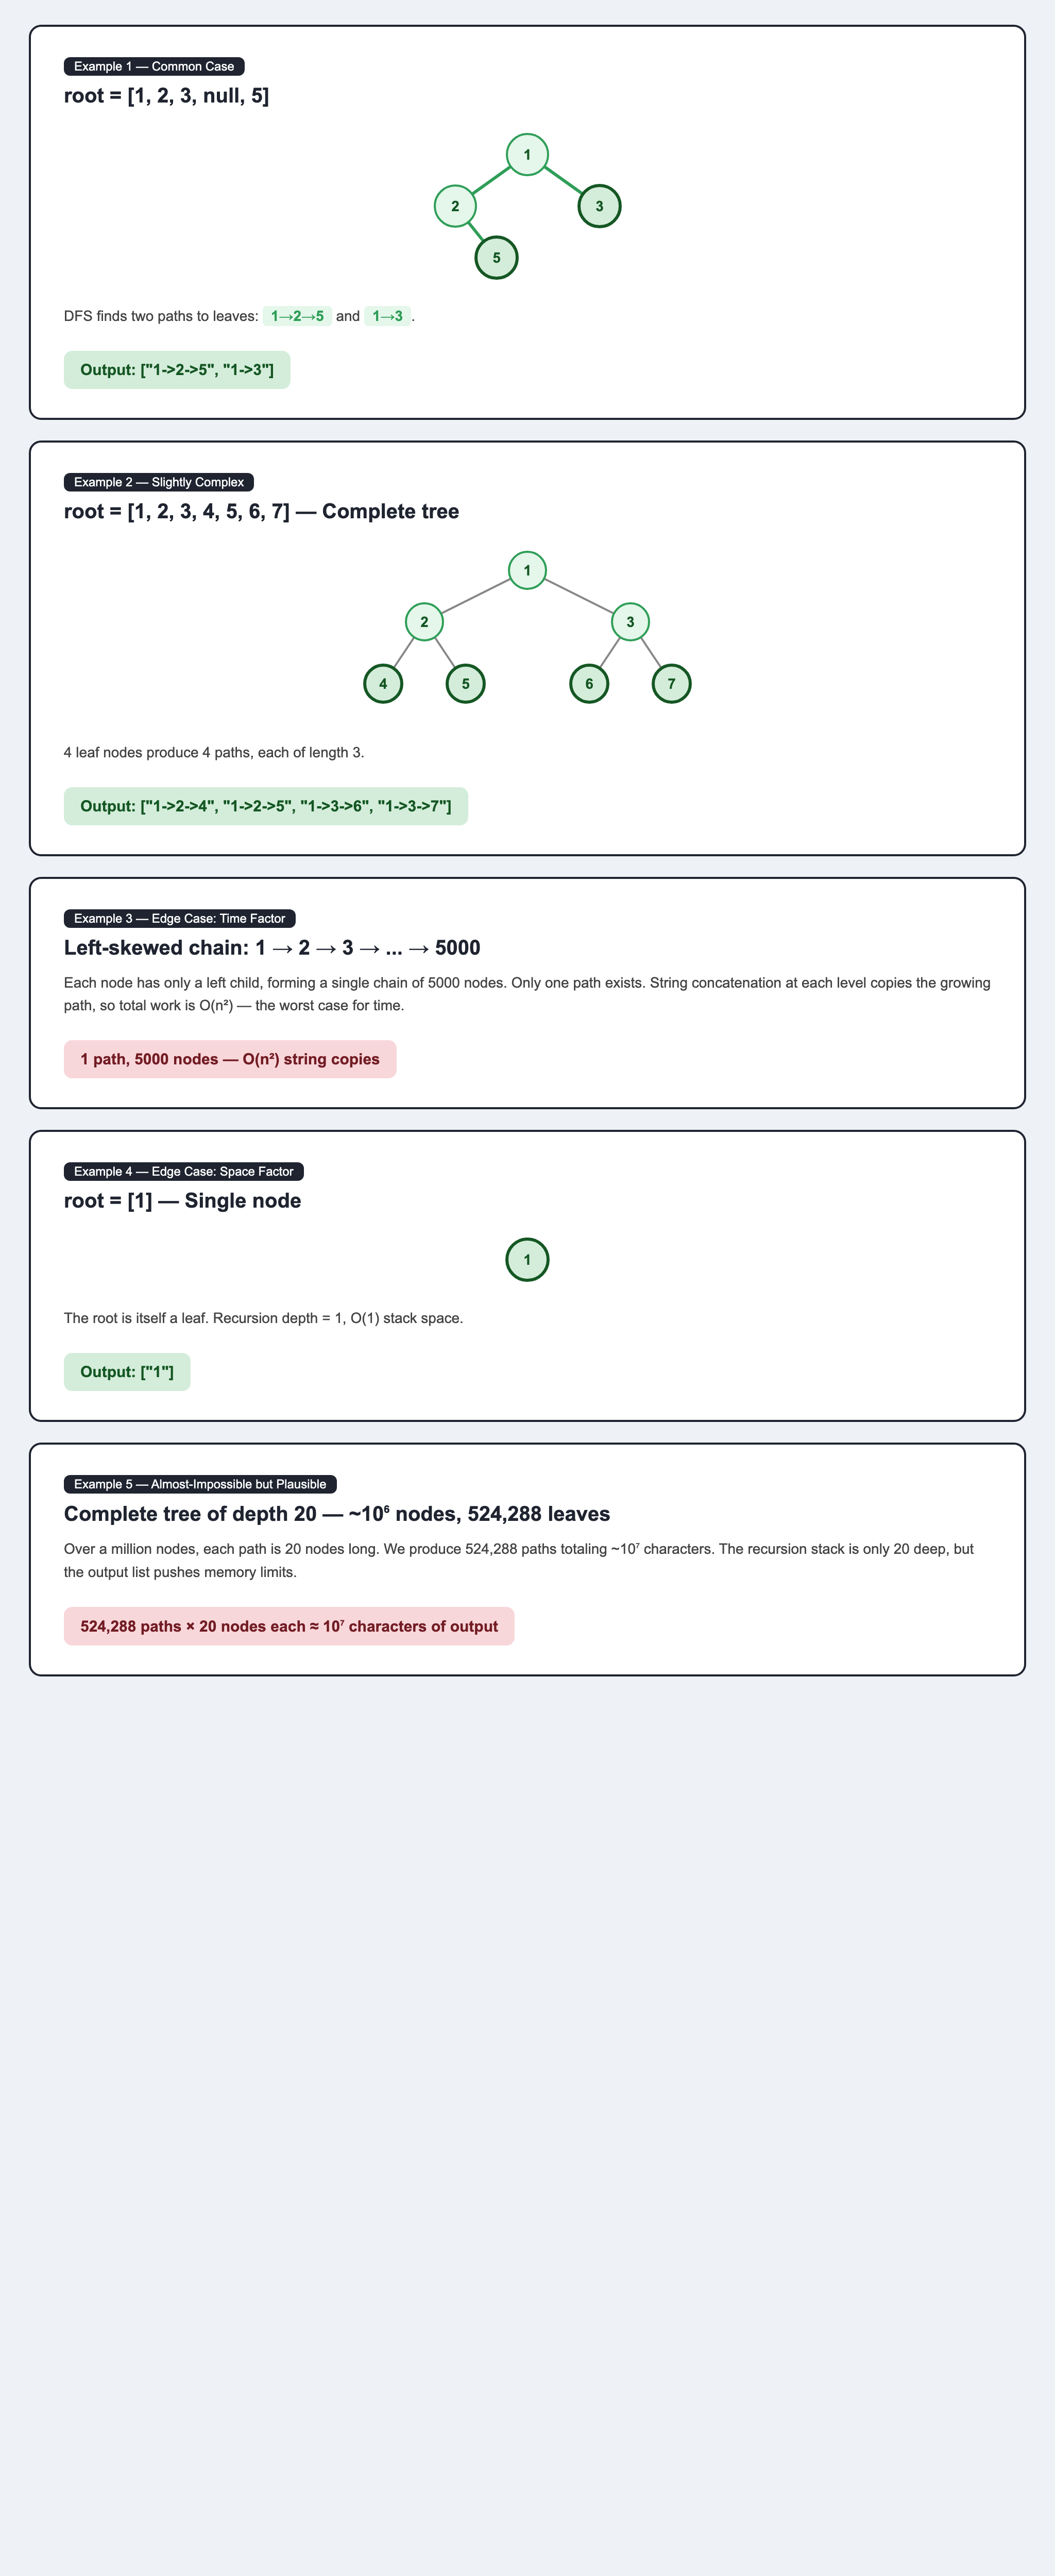